# **[HuBMAP 2023] - Torch Mask R-CNN**

This notebook is inspired from:
* https://www.kaggle.com/code/julian3833/sartorius-starter-torch-mask-r-cnn-lb-0-273
* https://www.kaggle.com/code/rluethy/sartorius-torch-mask-r-cnn

Thanks [Julián Peller](https://www.kaggle.com/julian3833) AND [ROLAND LUETHY](https://www.kaggle.com/rluethy)

In [1]:
!cp -r /kaggle/input/pycocotools/ /kaggle/working/pycocotools
!pip install /kaggle/working/pycocotools/pycocotools-2.0.6  --no-index --find-links=/kaggle/working/pycocotools/

Looking in links: /kaggle/working/pycocotools/
Processing ./pycocotools/pycocotools-2.0.6
  Installing build dependencies ... - \ | / done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Created wheel for pycocotools: filename=pycocotools-2.0.6-cp310-cp310-linux_x86_64.whl size=93516 sha256=32da0fd118c33d1d9b99b742fd6657308f68b20229cedc00f8cde31b260dd61c
  Stored in directory: /root/.cache/pip/wheels/33/be/1a/87ffe91b7dc6435df82208f620dbdcc654f3144d97550df6d8
Successfully built pycocotools


## Imports

In [2]:
import os
import random
import time
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import torch
import torchvision
from torchvision.transforms import ToPILImage
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

In [3]:
def fix_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    
fix_all_seeds(2021)

## Configuration

In [4]:
TEST = False
if os.path.exists("/kaggle/input/hubmap-hacking-the-human-vasculature"):
    # running on kaggle
    data_directory = '/kaggle/input/hubmap-hacking-the-human-vasculature'
    DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    BATCH_SIZE = 4
    NUM_EPOCHS = 10 

elif 'google.colab' in str(get_ipython()):
    # running on CoLab
    from google.colab import drive
    drive.mount('/content/drive')
    data_directory = '/content/drive/MyDrive/kaggle/[HuBMAP-2023]'
    DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    BATCH_SIZE = 16
    NUM_EPOCHS = 10
    
else:
    data_directory = 'input'
    DEVICE = torch.device('cpu')
    BATCH_SIZE = 2
    NUM_EPOCHS = 1
    TEST = True

TRAIN_CSV = "/kaggle/input/hubmap-dataframe/df_train.csv"

TRAIN_PATH = f"{data_directory}/train"
TEST_PATH = f"{data_directory}/test"

WIDTH = 512
HEIGHT = 512

resize_factor = False # 0.5

# Normalize to resnet mean and std if True.
NORMALIZE = False
RESNET_MEAN = (0.485, 0.456, 0.406)
RESNET_STD = (0.229, 0.224, 0.225)

# No changes tried with the optimizer yet.
MOMENTUM = 0.9
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0005

# cell type specific thresholds
cell_type_dict = {'blood_vessel': 1, 'glomerulus': 2, 'unsure': 3}
mask_threshold_dict = {1: 0.40, 2: 0.80, 3:  0.80}
min_score_dict = {1: 0.40, 2: 0.80, 3: 0.80}

# Use a StepLR scheduler if True. 
USE_SCHEDULER = False
TEST_SIZE=0.20
BOX_DETECTIONS_PER_IMG = 500

## Utilities

In [5]:
# ref: https://www.kaggle.com/inversion/run-length-decoding-quick-start
def rle_decode(mask_rle, shape, color=1):
    '''
    mask_rle: run-length as string formated (start length)
    shape: (height, width, channels) of array to return
    color: color for the mask
    Returns numpy array (mask)

    '''
    s = mask_rle.split()

    starts = list(map(lambda x: int(x) - 1, s[0::2]))
    lengths = list(map(int, s[1::2]))
    ends = [x + y for x, y in zip(starts, lengths)]
    if len(shape)==3:
        img = np.zeros((shape[0] * shape[1], shape[2]), dtype=np.float32)
    else:
        img = np.zeros(shape[0] * shape[1], dtype=np.float32)
    for start, end in zip(starts, ends):
        img[start : end] = color

    return img.reshape(shape)


def rle_encoding(x):
    dots = np.where(x.flatten() == 1)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if (b>prev+1): run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    return ' '.join(map(str, run_lengths))


def remove_overlapping_pixels(mask, other_masks):
    for other_mask in other_masks:
        if np.sum(np.logical_and(mask, other_mask)) > 0:
            mask[np.logical_and(mask, other_mask)] = 0
    return mask

def combine_masks(masks, mask_threshold):
    """
    combine masks into one image
    """
    maskimg = np.zeros((HEIGHT, WIDTH))
    # print(len(masks.shape), masks.shape)
    for m, mask in enumerate(masks,1):
        maskimg[mask>mask_threshold] = m
    return maskimg


def get_filtered_masks(pred):
    """
    filter masks using MIN_SCORE for mask and MAX_THRESHOLD for pixels
    """
    use_masks = []
    use_labels = []
    for i, mask in enumerate(pred["masks"]):
        # Filter-out low-scoring results. Not tried yet.
        scr = pred["scores"][i].cpu().item()
        label = pred["labels"][i].cpu().item()
        if scr > min_score_dict[label]:
            mask = mask.cpu().numpy().squeeze()
            # Keep only highly likely pixels
            binary_mask = mask > mask_threshold_dict[label]
            binary_mask = remove_overlapping_pixels(binary_mask, use_masks)
            use_masks.append(binary_mask)
            use_labels.append(label)

    return use_masks,use_labels


### Metric: mAP IoU threshold 0.6

In [6]:
def compute_iou(labels, y_pred, verbose=0):
    """
    Computes the IoU for instance labels and predictions.

    Args:
        labels (np array): Labels.
        y_pred (np array): predictions

    Returns:
        np array: IoU matrix, of size true_objects x pred_objects.
    """

    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))

    if verbose:
        print("Number of true objects: {}".format(true_objects))
        print("Number of predicted objects: {}".format(pred_objects))

    # Compute intersection between all objects
    intersection = np.histogram2d(
        labels.flatten(), y_pred.flatten(), bins=(true_objects, pred_objects)
    )[0]

    # Compute areas (needed for finding the union between all objects)
    area_true = np.histogram(labels, bins=true_objects)[0]
    area_pred = np.histogram(y_pred, bins=pred_objects)[0]
    area_true = np.expand_dims(area_true, -1)
    area_pred = np.expand_dims(area_pred, 0)

    # Compute union
    union = area_true + area_pred - intersection
    intersection = intersection[1:, 1:] # exclude background
    union = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union
    
    return iou  

def precision_at(threshold, iou):
    """
    Computes the precision at a given threshold.

    Args:
        threshold (float): Threshold.
        iou (np array): IoU matrix.

    Returns:
        int: Number of true positives,
        int: Number of false positives,
        int: Number of false negatives.
    """
    matches = iou > threshold
    true_positives = np.sum(matches, axis=1) == 1  # Correct objects
    false_positives = np.sum(matches, axis=0) == 0  # Missed objects
    false_negatives = np.sum(matches, axis=1) == 0  # Extra objects
    tp, fp, fn = (
        np.sum(true_positives),
        np.sum(false_positives),
        np.sum(false_negatives),
    )
    return tp, fp, fn

def iou_map(truths, preds, verbose=0):
    """
    Computes the metric for the competition.
    Masks contain the segmented pixels where each object has one value associated,
    and 0 is the background.

    Args:
        truths (list of masks): Ground truths.
        preds (list of masks): Predictions.
        verbose (int, optional): Whether to print infos. Defaults to 0.

    Returns:
        float: mAP.
    """
    ious = [compute_iou(truth, pred, verbose) for truth, pred in zip(truths, preds)]

    if verbose:
        print("Thresh\tTP\tFP\tFN\tPrec.")

    prec = []
    for t in np.arange(0.6, 6.5, 0.05):
        tps, fps, fns = 0, 0, 0
        for iou in ious:
            tp, fp, fn = precision_at(t, iou)
            tps += tp
            fps += fp
            fns += fn

        p = tps / (tps + fps + fns)
        prec.append(p)

        if verbose:
            print("{:1.3f}\t{}\t{}\t{}\t{:1.3f}".format(t, tps, fps, fns, p))

    if verbose:
        print("AP\t-\t-\t-\t{:1.3f}".format(np.mean(prec)))

    return np.mean(prec)


def get_score(ds, mdl):
    """
    Get average IOU mAP score for a dataset
    """
    mdl.eval()
    iouscore = 0
    for i in tqdm(range(len(ds))):
        img, targets = ds[i]
        with torch.no_grad():
            result = mdl([img.to(DEVICE)])[0]
            
        masks = combine_masks(targets['masks'], 0.5)
        labels = pd.Series(result['labels'].cpu().numpy()).value_counts()

        mask_threshold = mask_threshold_dict[labels.sort_values().index[-1]]
        masks_p,labels_p=get_filtered_masks(result)
        pred_masks = combine_masks(masks_p, mask_threshold)
        iouscore += iou_map([masks],[pred_masks])
    return iouscore / len(ds)


### Transformations
Just Horizontal and Vertical Flip for now.

Normalization to Resnet's mean and std can be performed using the parameter `NORMALIZE` in the top cell.

The first 3 transformations come from [this](https://www.kaggle.com/abhishek/maskrcnn-utils) utils package by Abishek, `VerticalFlip` is my adaption of HorizontalFlip, and `Normalize` is of my own.

In [7]:
# These are slight redefinitions of torch.transformation classes
# The difference is that they handle the target and the mask
# Copied from Abishek, added new ones
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

class VerticalFlip:
    def __init__(self, prob):
        self.prob = prob

    def __call__(self, image, target):
        if random.random() < self.prob:
            height, width = image.shape[-2:]
            image = image.flip(-2)
            bbox = target["boxes"]
            bbox[:, [1, 3]] = height - bbox[:, [3, 1]]
            target["boxes"] = bbox
            target["masks"] = target["masks"].flip(-2)
        return image, target

class HorizontalFlip:
    def __init__(self, prob):
        self.prob = prob

    def __call__(self, image, target):
        if random.random() < self.prob:
            height, width = image.shape[-2:]
            image = image.flip(-1)
            bbox = target["boxes"]
            bbox[:, [0, 2]] = width - bbox[:, [2, 0]]
            target["boxes"] = bbox
            target["masks"] = target["masks"].flip(-1)
        return image, target

class Normalize:
    def __call__(self, image, target):
        image = F.normalize(image, RESNET_MEAN, RESNET_STD)
        return image, target

class ToTensor:
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target
    

def get_transform(train):
    transforms = [ToTensor()]
    if NORMALIZE:
        transforms.append(Normalize())
    
    # Data augmentation for train
    if train: 
        transforms.append(HorizontalFlip(0.5))
        transforms.append(VerticalFlip(0.5))

    return Compose(transforms)

## Training Dataset and DataLoader

In [8]:
cell_type_dict = {'blood_vessel': 1, 'glomerulus': 2, 'unsure': 3}
class HuBMAPDataset(Dataset):
    def __init__(self, image_dir, df, transforms=None, resize=False):
        self.transforms = transforms
        self.image_dir = image_dir
        self.df = df
        
        self.should_resize = resize is not False
        if self.should_resize:
            self.height = int(HEIGHT * resize)
            self.width = int(WIDTH * resize)
            print("image size used:", self.height, self.width)
        else:
            self.height = HEIGHT
            self.width = WIDTH
        
        self.image_info = collections.defaultdict(dict)
        temp_df = self.df.groupby(["image_id"])[['annotations','category_id']].agg(lambda x: list(x)).reset_index()
        for index, row in temp_df.iterrows():
            self.image_info[index] = {
                    'image_id': row['image_id'],
                    'image_path': os.path.join(self.image_dir, row['image_id'] + '.tif'),
                    'annotations': list(row["annotations"]),
                    'category_name': list(row["category_id"])
                    }
            
    def get_box(self, a_mask):
        ''' Get the bounding box of a given mask '''
        pos = np.where(a_mask)
        xmin = np.min(pos[1])
        xmax = np.max(pos[1])
        ymin = np.min(pos[0])
        ymax = np.max(pos[0])
        return [xmin, ymin, xmax, ymax]

    def __getitem__(self, idx):
        ''' Get the image and the target'''
        
        img_path = self.image_info[idx]["image_path"]
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        info = self.image_info[idx]

        n_objects = len(info['annotations'])
        masks = np.zeros((len(info['annotations']), self.height, self.width), dtype=np.uint8)
        boxes = []
        labels = []
        for i, annotation in enumerate(info['annotations']):
            a_mask = rle_decode(annotation, (HEIGHT, WIDTH))        
            a_mask = np.array(a_mask) > 0
            masks[i, :, :] = a_mask
            boxes.append(self.get_box(a_mask))
        labels = info["category_name"]        
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)
        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((n_objects,), dtype=torch.int64)
        target = {
            'boxes': boxes,
            'labels': labels,
            'masks': masks,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target#,img_path

    def __len__(self):
        return len(self.image_info)

## Reading Dataset

In [9]:
df_ = pd.read_csv(TRAIN_CSV)
df_.head(3)

,Unnamed: 0,image_id,category_id,category_name,annotations,bbox,area,iscrowd
0,0,0006ff2aa7cd,2,glomerulus,2 253 513 254 1025 254 1537 254 2049 254 2561 ...,"(0, 0, 271, 250)",56426,0
1,1,0006ff2aa7cd,1,blood_vessel,37657 3 38167 7 38678 8 39190 10 39701 11 4021...,"(272, 73, 20, 37)",570,0
2,2,0006ff2aa7cd,1,blood_vessel,121934 3 122444 7 122955 9 123466 10 123978 11...,"(72, 238, 37, 55)",1027,0


In [10]:
df_images = df_.groupby(["image_id", "category_name"]).agg({'annotations': 'count'}).sort_values("annotations", ascending=False).reset_index()

In [11]:
# Use the quantiles of amoount of annotations to stratify
df_images_train, df_images_val = train_test_split(df_images, stratify=df_images['category_name'], 
                                                  test_size=TEST_SIZE,
                                                  random_state=1234)
df_train = df_[df_['image_id'].isin(df_images_train['image_id'])]
df_val = df_[df_['image_id'].isin(df_images_val['image_id'])]

In [12]:
ds_train = HuBMAPDataset(TRAIN_PATH, df_train, resize=resize_factor, transforms=get_transform(train=True))
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True,
                      num_workers=2, collate_fn=lambda x: tuple(zip(*x)))

ds_val = HuBMAPDataset(TRAIN_PATH, df_val, resize=resize_factor, transforms=get_transform(train=False))
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True,
                    num_workers=2, collate_fn=lambda x: tuple(zip(*x)))

# Train model

## setup model

In [13]:
!mkdir -p /root/.cache/torch/hub/checkpoints/
!cp ../input/cocopre/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth

In [14]:
def get_model(num_classes, model_chkpt=None):    
    if NORMALIZE:
        model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True,
                                                                   box_detections_per_img=BOX_DETECTIONS_PER_IMG,
                                                                   image_mean=RESNET_MEAN,
                                                                   image_std=RESNET_STD)
    else:
        model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True,
                                                                   box_detections_per_img=BOX_DETECTIONS_PER_IMG)

    # get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes+1)
    # now get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes+1)
    if model_chkpt:
        model.load_state_dict(torch.load(model_chkpt, map_location=DEVICE))
    return model
# Get the Mask R-CNN model
# The model does classification, bounding boxes and MASKs for individuals, all at the same time
# We only care about MASKS
model = get_model(len(cell_type_dict))
model.to(DEVICE)

# TODO: try removing this for
for param in model.parameters():
    param.requires_grad = True
    
model.train();

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Training loop!

In [15]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
#optimizer = torch.optim.Adam(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
n_batches, n_batches_val = len(dl_train), len(dl_val)
validation_mask_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Starting epoch {epoch} of {NUM_EPOCHS}")

    time_start = time.time()
    loss_accum = 0.0
    loss_mask_accum = 0.0
    loss_classifier_accum = 0.0
    for batch_idx, (images, targets) in enumerate(dl_train, 1):
    
        # Predict
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        
        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Logging
        loss_mask = loss_dict['loss_mask'].item()
        loss_accum += loss.item()
        loss_mask_accum += loss_mask
        loss_classifier_accum += loss_dict['loss_classifier'].item()
        
        if batch_idx % 500 == 0:
            print(f"    [Batch {batch_idx:3d} / {n_batches:3d}] Batch train loss: {loss.item():7.3f}. Mask-only loss: {loss_mask:7.3f}.")
                        
    if USE_SCHEDULER:
        lr_scheduler.step()

    # Train losses
    train_loss = loss_accum / n_batches
    train_loss_mask = loss_mask_accum / n_batches
    train_loss_classifier = loss_classifier_accum / n_batches

    # Validation
    val_loss_accum = 0
    val_loss_mask_accum = 0
    val_loss_classifier_accum = 0
    
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(dl_val, 1):
            images = list(image.to(DEVICE) for image in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            val_loss_dict = model(images, targets)
            val_batch_loss = sum(loss for loss in val_loss_dict.values())
            val_loss_accum += val_batch_loss.item()
            val_loss_mask_accum += val_loss_dict['loss_mask'].item()
            val_loss_classifier_accum += val_loss_dict['loss_classifier'].item()

    # Validation losses
    val_loss = val_loss_accum / n_batches_val
    val_loss_mask = val_loss_mask_accum / n_batches_val
    val_loss_classifier = val_loss_classifier_accum / n_batches_val
    elapsed = time.time() - time_start

    validation_mask_losses.append(val_loss_mask)

    torch.save(model.state_dict(), f"pytorch_model-e{epoch}.bin")
    prefix = f"[Epoch {epoch:2d}/{NUM_EPOCHS:2d}]"
    print(f"{prefix} -- train mask loss: {train_loss_mask:7.3f}, classes loss {train_loss_classifier:7.3f}")
    print(f"{prefix} -- val mask loss  : {val_loss_mask:7.3f}, classes loss {val_loss_classifier:7.3f}")
    print(f"{prefix} -- train loss: {train_loss:7.3f}. val loss: {val_loss:7.3f} [{elapsed:.0f} secs]")
    print("---------------------------------------------------------------------------------------------")

Starting epoch 1 of 10
[Epoch  1/10] -- train mask loss:   0.348, classes loss   0.342
[Epoch  1/10] -- val mask loss  :   0.306, classes loss   0.310
[Epoch  1/10] -- train loss:   1.319. val loss:   1.185 [530 secs]
---------------------------------------------------------------------------------------------
Starting epoch 2 of 10
[Epoch  2/10] -- train mask loss:   0.294, classes loss   0.278
[Epoch  2/10] -- val mask loss  :   0.293, classes loss   0.272
[Epoch  2/10] -- train loss:   1.108. val loss:   1.093 [535 secs]
---------------------------------------------------------------------------------------------
Starting epoch 3 of 10
[Epoch  3/10] -- train mask loss:   0.284, classes loss   0.261
[Epoch  3/10] -- val mask loss  :   0.273, classes loss   0.255
[Epoch  3/10] -- train loss:   1.052. val loss:   1.026 [537 secs]
---------------------------------------------------------------------------------------------
Starting epoch 4 of 10
[Epoch  4/10] -- train mask loss:   0.278

# Analyze prediction results for train set

60


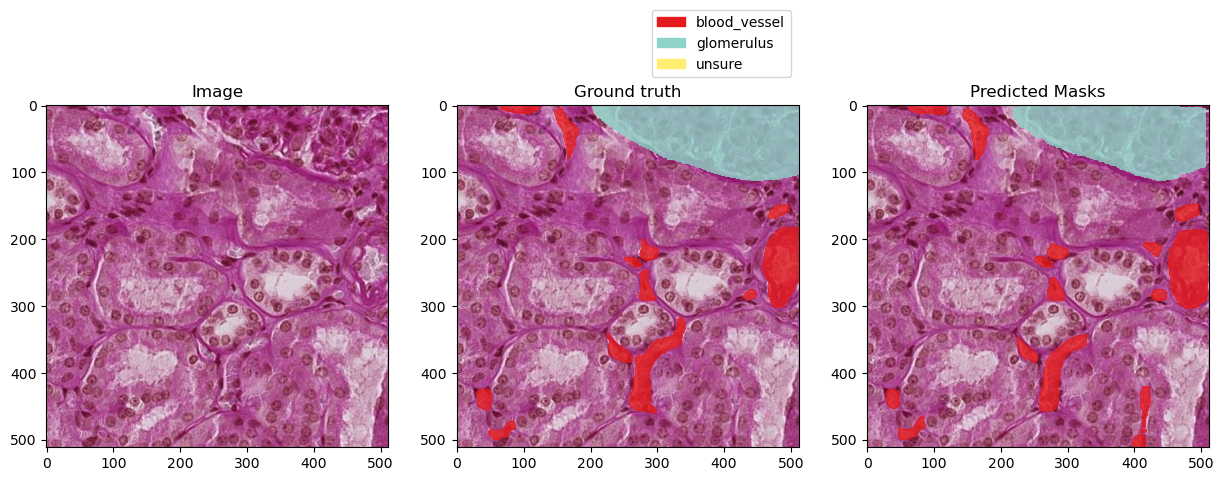

In [16]:
colors = [ 'Set1', 'Set3','Set3_r'] 
legend = {0: 'blood_vessel',1: 'glomerulus', 2: 'unsure'}
img, targets = ds_train[17]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img.numpy().transpose((1,2,0)))
axs[0].set_title('Image')
axs[1].imshow(img.numpy().transpose((1,2,0)))
# Loop over each mask and its label in the targets dictionary
for mask, lbl in zip(targets['masks'], targets['labels']):
    mask = np.ma.masked_where(mask == 0, mask)
    color = colors[lbl.item()-1]
    axs[1].imshow(mask, cmap=color, alpha=0.8)
    axs[1].set_title('Ground truth')
    handles = []
    for cl in legend:
        color = colors[cl]
        handles.append(mpatches.Patch(color=plt.colormaps.get_cmap(color)(0)))
    axs[1].legend(handles, legend.values(), bbox_to_anchor=(0.55, 1.3), loc='upper left')
model.eval()
with torch.no_grad():
    preds = model([img.to(DEVICE)])[0]
print(len(preds["labels"]))
axs[2].imshow(img.numpy().transpose((1,2,0)))
masks,labels=get_filtered_masks(preds)
for mask ,lbl in zip(masks,labels):
    color = colors[lbl-1]
    mask = np.ma.masked_where(mask == 0, mask)
    axs[2].imshow(mask, cmap=color, alpha=0.8)
    axs[2].set_title('Predicted Masks')


## Get the best model

In [17]:
# Epochs with their losses and IOU scores
val_scores = pd.DataFrame()
for e, val_loss in enumerate(validation_mask_losses):
    model_chk = f"pytorch_model-e{e+1}.bin"
    print("Loading:", model_chk)
    model = get_model(len(cell_type_dict), model_chk)
    model.load_state_dict(torch.load(model_chk))
    model = model.to(DEVICE)
    val_scores.loc[e,"mask_loss"] = val_loss
    val_scores.loc[e,"score"] = get_score(ds_val, model)
     
display(val_scores.sort_values("score", ascending=False))
best_epoch = np.argmax(val_scores["score"])
print(best_epoch+1)

Loading: pytorch_model-e1.bin


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  0%|          | 0/452 [00:00<?, ?it/s]

Loading: pytorch_model-e2.bin


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...

Loading: pytorch_model-e10.bin


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  0%|          | 0/452 [00:00<?, ?it/s]

,mask_loss,score
9,0.256729,0.012521
6,0.261840,0.011087
7,0.268944,0.010703
8,0.273932,0.010449
4,0.268227,0.010078
5,0.269813,0.009586
3,0.270096,0.009441
2,0.272899,0.009344
1,0.293455,0.007191
0,0.306225,0.005264


10


# Prediction

## Test Dataset and DataLoader

In [18]:
class HuBMAPTestDataset(Dataset):
    def __init__(self, image_dir, transforms=None):
        self.transforms = transforms
        self.image_dir = image_dir
        self.image_ids = [f[:-4]for f in os.listdir(self.image_dir)]

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.image_dir, image_id + '.tif')
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)

        if self.transforms is not None:
            image, _ = self.transforms(image=image, target=None)
        return {'image': image, 'image_id': image_id,'image_path':image_path}

    def __len__(self):
        return len(self.image_ids)

In [19]:
ds_test = HuBMAPTestDataset(TEST_PATH, transforms=get_transform(train=False))

In [20]:
import typing as t
from pycocotools import _mask as coco_mask
import zlib
import base64
def encode_binary_mask(mask: np.ndarray) -> t.Text:
    # check input mask --
    if mask.dtype != bool:
        raise ValueError(
            "encode_binary_mask expects a binary mask, received dtype == %s" %
            mask.dtype)

    mask = np.squeeze(mask)
    if len(mask.shape) != 2:
        raise ValueError(
            "encode_binary_mask expects a 2d mask, received shape == %s" %
            mask.shape)

    # convert input mask to expected COCO API input --
    mask_to_encode = mask.reshape(mask.shape[0], mask.shape[1], 1)
    mask_to_encode = mask_to_encode.astype(np.uint8)
    mask_to_encode = np.asfortranarray(mask_to_encode)

    # RLE encode mask --
    encoded_mask = coco_mask.encode(mask_to_encode)[0]["counts"]

    # compress and base64 encoding --
    binary_str = zlib.compress(encoded_mask, zlib.Z_BEST_COMPRESSION)
    base64_str = base64.b64encode(binary_str)
    return base64_str

In [21]:
model_chk = f"pytorch_model-e{best_epoch+1}.bin"
print("Loading:", model_chk)
model = get_model(len(cell_type_dict))
model.load_state_dict(torch.load(model_chk))
model = model.to(DEVICE)

for param in model.parameters():
    param.requires_grad = False

model.eval();

submission = []
for sample in ds_test:
    img = sample['image']
    image_id = sample['image_id']
    image_path = sample['image_path']
    h, w, _ = cv2.imread(image_path).shape
    with torch.no_grad():
        result = model([img.to(DEVICE)])[0]
    
    previous_masks = []
    masks_use = []
    labels_use = []
    pred_string=""
    for i, mask in enumerate(result["masks"]):
        # Filter-out low-scoring results.
        score = result["scores"][i].cpu().item()
        label = result["labels"][i].cpu().item()
        if score > min_score_dict[label]:
            mask = mask.cpu().numpy()
            # Keep only highly likely pixels
            binary_mask = mask > mask_threshold_dict[label]
            binary_mask = remove_overlapping_pixels(binary_mask, previous_masks)
            masks_use.append(binary_mask)
            labels_use.append(label)
            previous_masks.append(binary_mask)
            encoded = encode_binary_mask(binary_mask)
            label=label-1
            if label != 0: continue
            if i == 0:
                pred_string += f"{int(label)} {score} {encoded.decode('utf-8')}"
            else:
                pred_string += f" {int(label)} {score} {encoded.decode('utf-8')}"

    submission.append((image_id,w,h, pred_string))


Loading: pytorch_model-e10.bin


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


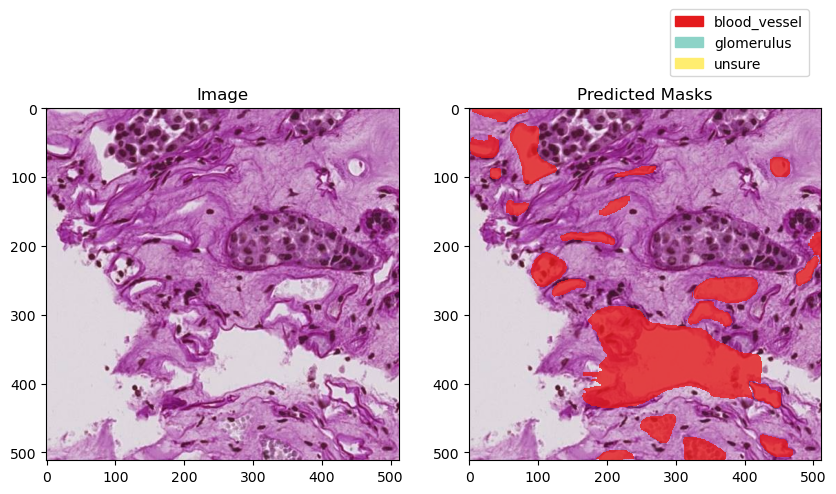

In [22]:
colors = [ 'Set1', 'Set3','Set3_r'] 
legend = {0: 'blood_vessel',1: 'glomerulus', 2: 'unsure'}
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img.numpy().transpose((1,2,0)))
axs[0].set_title('Image')
axs[1].imshow(img.numpy().transpose((1,2,0)))
# Loop over each mask and its label in the targets dictionary
for mask, lbl in zip(masks_use, labels_use):
    mask = np.ma.masked_where(mask[0] == 0, mask[0])
    color = colors[lbl-1]
    axs[1].imshow(mask, cmap=color, alpha=0.8)
    axs[1].set_title('Predicted Masks')
    handles = []
    for cl in legend:
        color = colors[cl]
        handles.append(mpatches.Patch(color=plt.colormaps.get_cmap(color)(0)))
    axs[1].legend(handles, legend.values(), bbox_to_anchor=(0.55, 1.3), loc='upper left')


In [23]:
df_sub = pd.DataFrame(submission, columns=['id','height','width','prediction_string'])
df_sub.to_csv("submission.csv", index=False)
df_sub.head()

,id,height,width,prediction_string
0,72e40acccadf,512,512,0 0.9631965756416321 eNoLiM82sUq2zzCI9jf0N8AFE...
